# Google playstore Analysis

In [1]:
import numpy as np
import pandas as pd

from matplotlib import pyplot as plt
import seaborn as sns

In [2]:
# Loading dataset

dataset=pd.read_csv("googleplaystore.csv")
dataset.head(5)

,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19M,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,Coloring book moana,ART_AND_DESIGN,3.9,967,14M,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7M,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25M,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8M,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up


In [3]:
column=dataset.columns
column

len(column)

13

In [4]:
print(dataset.info())
print(dataset.describe())

<class 'pandas.DataFrame'>
RangeIndex: 10841 entries, 0 to 10840
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             10841 non-null  str    
 1   Category        10841 non-null  str    
 2   Rating          9367 non-null   float64
 3   Reviews         10841 non-null  str    
 4   Size            10841 non-null  str    
 5   Installs        10841 non-null  str    
 6   Type            10840 non-null  str    
 7   Price           10841 non-null  str    
 8   Content Rating  10840 non-null  str    
 9   Genres          10841 non-null  str    
 10  Last Updated    10841 non-null  str    
 11  Current Ver     10833 non-null  str    
 12  Android Ver     10838 non-null  str    
dtypes: float64(1), str(12)
memory usage: 2.2 MB
None
            Rating
count  9367.000000
mean      4.193338
std       0.537431
min       1.000000
25%       4.000000
50%       4.300000
75%       4.500000
max      19.000000


In [5]:
# step 2: Data Cleaning

#1) convert data types for better analysis

print(dataset.dtypes)

App                   str
Category              str
Rating            float64
Reviews               str
Size                  str
Installs              str
Type                  str
Price                 str
Content Rating        str
Genres                str
Last Updated          str
Current Ver           str
Android Ver           str
dtype: object


In [6]:
dataset['Installs']=dataset['Installs'].astype(str).str.replace("Free","0")

dataset['Installs']=dataset['Installs'].str.replace(r"[+,]", "",regex=True).astype(float)


dataset['Price']=pd.to_numeric(dataset['Price'], errors="coerce")

dataset['Last Updated']=pd.to_datetime(dataset['Last Updated'], errors='coerce')

In [7]:
print(dataset.dtypes)

App                          str
Category                     str
Rating                   float64
Reviews                      str
Size                         str
Installs                 float64
Type                         str
Price                    float64
Content Rating               str
Genres                       str
Last Updated      datetime64[us]
Current Ver                  str
Android Ver                  str
dtype: object


In [8]:
# Handling Misssing Values
# 1) Indentifying null columns

dataset.isna().sum()  # count missing data

App                  0
Category             0
Rating            1474
Reviews              0
Size                 0
Installs             0
Type                 1
Price                1
Content Rating       1
Genres               0
Last Updated         1
Current Ver          8
Android Ver          3
dtype: int64

In [9]:
dataset['Rating']=dataset['Rating'].fillna(dataset['Rating'].median())

dataset['Price'].fillna(dataset['Price'].median(), inplace=True)

dataset['Current Ver']=dataset['Current Ver'].fillna(dataset['Current Ver'].mode()[0])

dataset['Android Ver']=dataset['Android Ver'].fillna(dataset['Android Ver'].mode()[0])

dataset['Content Rating']=dataset['Content Rating'].fillna(dataset['Content Rating'].mode()[0])

dataset['Type']=dataset['Type'].fillna(dataset['Type'].mode()[0])

dataset['Last Updated']=dataset['Last Updated'].fillna(dataset['Last Updated'].mode()[0])


C:\Users\kotes\AppData\Local\Temp\ipykernel_28812\79964234.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  dataset['Price'].fillna(dataset['Price'].median(), inplace=True)


In [10]:
# Identifying and removing Duplicates

dataset.duplicated().sum()    # gives number of duplicates

483

In [11]:
dataset.drop_duplicates(keep='first', inplace=True)    ## Removed all duplicates

In [12]:
dataset.duplicated().sum()    # gives number of duplicates

0

In [13]:
# Detect Outliers and Remove Them
dataset.describe()


,Rating,Installs,Price,Last Updated
count,10358.000000,1.035800e+04,10357.000000,10358
mean,4.205165,1.415639e+07,1.030800,2017-11-14 10:01:41.486773
min,1.000000,0.000000e+00,0.000000,2010-05-21 00:00:00
25%,4.100000,1.000000e+03,0.000000,2017-09-03 00:00:00
50%,4.300000,1.000000e+05,0.000000,2018-05-20 00:00:00
75%,4.500000,1.000000e+06,0.000000,2018-07-19 00:00:00
max,19.000000,1.000000e+09,400.000000,2018-08-08 00:00:00
std,0.506868,8.023580e+07,16.278625,NaN


<Axes: ylabel='Rating'>

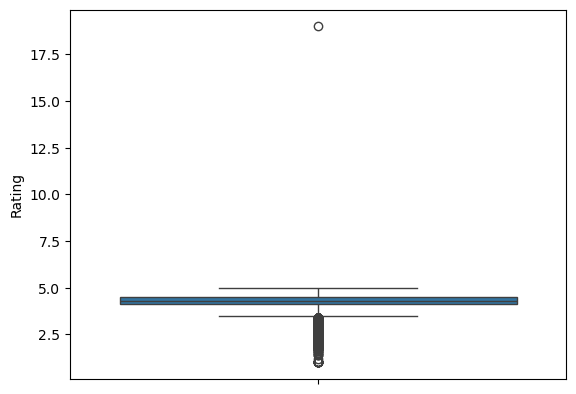

In [14]:
sns.boxplot(dataset['Rating'])

<Axes: ylabel='Price'>

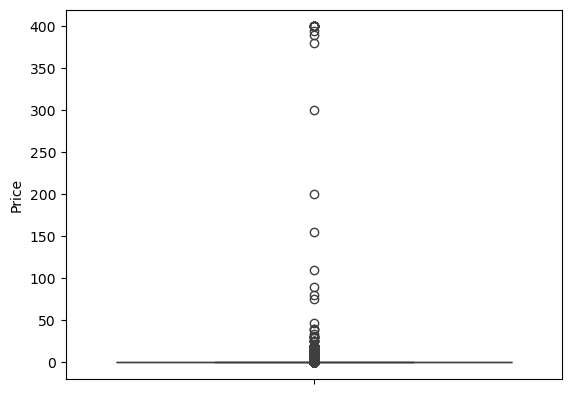

In [15]:
sns.boxplot(dataset['Price'])

In [16]:
# Saving the changes of all as backup
dataset_backup=dataset.copy()

In [17]:
(dataset['Rating']>5).sum()

1

In [18]:
dataset=dataset[dataset['Rating'] <=5]
dataset['Rating'].describe()

count    10357.000000
mean         4.203737
std          0.485594
min          1.000000
25%          4.100000
50%          4.300000
75%          4.500000
max          5.000000
Name: Rating, dtype: float64

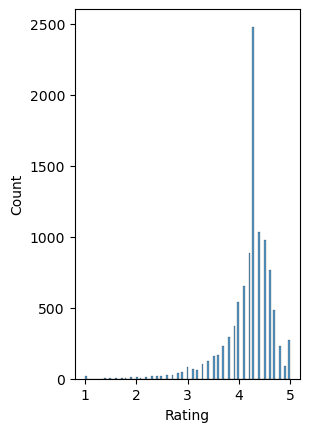

In [19]:
plt.subplot(1,2,1)
sns.histplot(dataset['Rating']) #checking after removing outliers
plt.show()

In [20]:
dataset['Rating'].describe()

count    10357.000000
mean         4.203737
std          0.485594
min          1.000000
25%          4.100000
50%          4.300000
75%          4.500000
max          5.000000
Name: Rating, dtype: float64

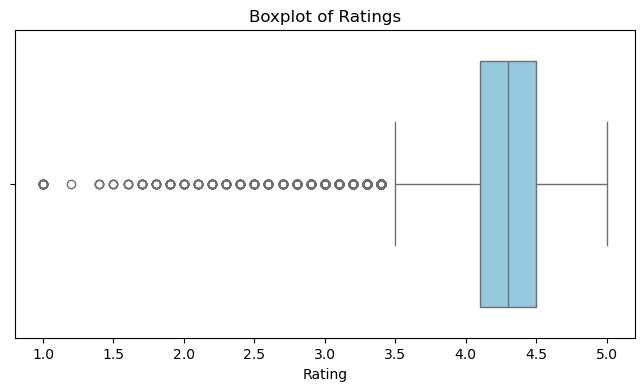

In [21]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=dataset['Rating'],color='skyblue')
plt.title("Boxplot of Ratings")
plt.show()

In [22]:
dataset['Price'].describe()

count    10357.000000
mean         1.030800
std         16.278625
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max        400.000000
Name: Price, dtype: float64

In [23]:
# Capping Outliers using Percentile

upper_cap = dataset['Price'].quantile(0.95)   # set upper limit at 95th percentile

dataset['Price']= dataset['Price'].clip(upper = upper_cap) # Cap values above 95th percentile
dataset['Price'].describe()

count    10357.000000
mean         0.129848
std          0.472514
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.990000
Name: Price, dtype: float64

In [24]:
dataset.to_csv("cleaned_dataset.csv", index=False)